In [57]:
# Install and import everything
!pip install nltk -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score
import nltk
from nltk.corpus import stopwords
import re
nltk.download('stopwords', quiet=True)

print("✅ Setup complete!")

✅ Setup complete!


📊 Dataset size: 5572 messages
📈 Spam vs Ham: 
label
ham     4825
spam     747
Name: count, dtype: int64


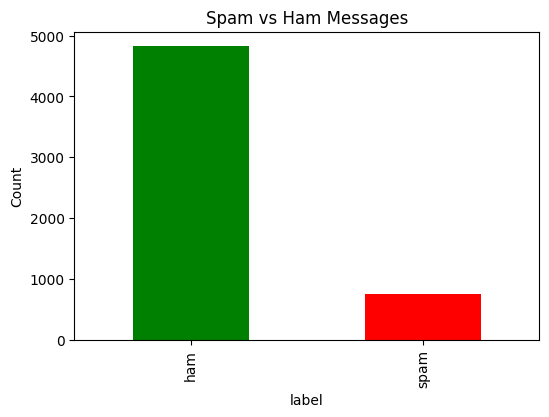

In [56]:
# Load your spam.csv file
df = pd.read_csv('spam.csv', encoding='latin-1')

# Clean up columns - keep only what we need
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(f"📊 Dataset size: {df.shape[0]} messages")
print(f"📈 Spam vs Ham: \n{df['label'].value_counts()}")

# Quick visualization
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Spam vs Ham Messages')
plt.ylabel('Count')
plt.show()

In [55]:
def clean_text(text):
    """Simple text cleaning function"""
    # Make lowercase
    text = text.lower()
    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

# Clean all messages
df['cleaned'] = df['message'].apply(clean_text)

# Show example
print("Before:", df['message'].iloc[0])
print("After: ", df['cleaned'].iloc[0])

Before: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
After:  go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [53]:
# Convert text to numbers using TF-IDF
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(df['cleaned'])
y = df['label'].map({'ham': 0, 'spam': 1})

print(f"✅ Features created: {X.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

✅ Features created: (5572, 3000)


In [58]:
# Train logistic regression
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"🎯 Model Accuracy: {accuracy:.2%}")

🎯 Model Accuracy: 98.39%


📊 Model Performance:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



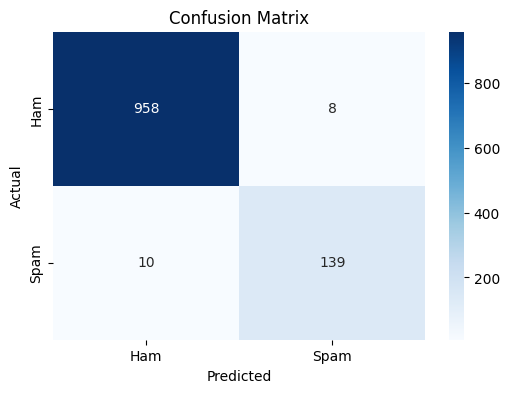

In [51]:
# Classification report (easy to read)
print("📊 Model Performance:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

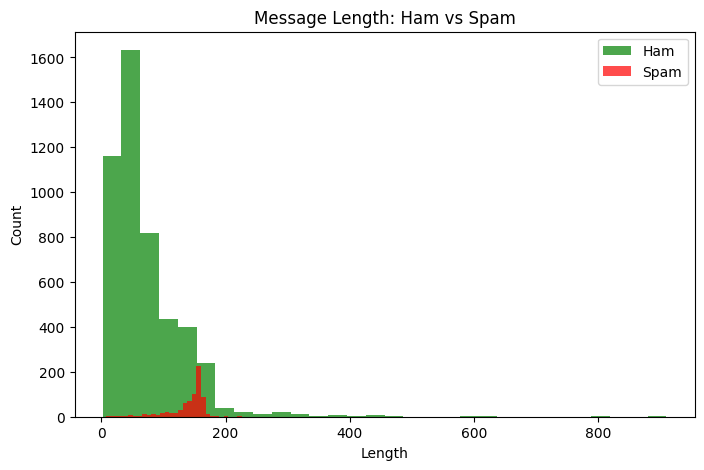

In [50]:
# Add message length
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df[df['label']=='ham']['length'], bins=30, alpha=0.7, label='Ham', color='green')
plt.hist(df[df['label']=='spam']['length'], bins=30, alpha=0.7, label='Spam', color='red')
plt.legend()
plt.title('Message Length: Ham vs Spam')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

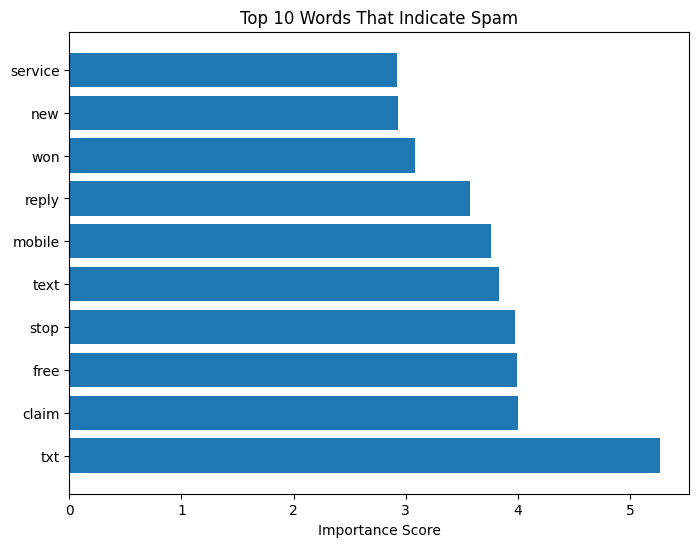

🔍 Top Spam Words: ['service', 'new', 'won', 'reply', 'mobile', 'text', 'stop', 'free', 'claim', 'txt']


In [49]:
# Get top spam words
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top 10 spam words
top_spam_idx = np.argsort(coefficients)[-10:]
top_spam_words = [feature_names[i] for i in top_spam_idx]

plt.figure(figsize=(8,6))
plt.barh(range(10), coefficients[top_spam_idx])
plt.yticks(range(10), top_spam_words)
plt.xlabel('Importance Score')
plt.title('Top 10 Words That Indicate Spam')
plt.gca().invert_yaxis()
plt.show()

print("🔍 Top Spam Words:", top_spam_words)

In [48]:
def predict_message(message):
    """Predict if message is spam or not"""
    # Clean message
    cleaned = clean_text(message)
    # Convert to numbers
    X_new = vectorizer.transform([cleaned])
    # Predict
    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0]

    result = 'Spam' if prediction == 1 else 'Ham'
    confidence = max(probability)

    return f"{result} (Confidence: {confidence:.2%})"

# Test some messages
test_messages = [
    "Hey, meeting at 3pm today?",
    "WIN £1000 CASH! Call 0800 123 456 now!",
    "Don't forget to buy milk",
    "FREE iPhone! Click here to claim!",
    "How's your day going?"
]

print("🧪 Testing New Messages:")
for msg in test_messages:
    print(f"Message: {msg}")
    print(f"Prediction: {predict_message(msg)}")
    print("-" * 40)

🧪 Testing New Messages:
Message: Hey, meeting at 3pm today?
Prediction: Ham (Confidence: 90.45%)
----------------------------------------
Message: WIN £1000 CASH! Call 0800 123 456 now!
Prediction: Spam (Confidence: 90.35%)
----------------------------------------
Message: Don't forget to buy milk
Prediction: Ham (Confidence: 82.24%)
----------------------------------------
Message: FREE iPhone! Click here to claim!
Prediction: Spam (Confidence: 91.83%)
----------------------------------------
Message: How's your day going?
Prediction: Ham (Confidence: 92.05%)
----------------------------------------


In [46]:
import joblib

# Save model
joblib.dump(model, 'spam_model.pkl')
joblib.dump(vectorizer, 'text_vectorizer.pkl')
print("💾 Model saved!")

💾 Model saved!


In [29]:
# Quick demo - words that trigger spam detection
spam_indicators = ['free', 'win', 'prize', 'cash', 'urgent', 'call', 'now', 'claim']
print("🚨 Common Spam Indicators:", ", ".join(spam_indicators))

🚨 Common Spam Indicators: free, win, prize, cash, urgent, call, now, claim


In [30]:
# Simple example
raw = "HELLO!!! I won $1000 FREE!!! Call NOW!!!"
cleaned = clean_text(raw)
print(f"Raw: {raw}")
print(f"Clean: {cleaned}")

Raw: HELLO!!! I won $1000 FREE!!! Call NOW!!!
Clean: hello i won free call now


In [31]:
print("📚 TF-IDF Explained:")
print("• TF = How often a word appears in a message")
print("• IDF = How rare the word is across all messages")
print("• TF-IDF = TF × IDF (important = frequent + rare)")
print("• Example: 'FREE' has high TF-IDF in spam messages")

📚 TF-IDF Explained:
• TF = How often a word appears in a message
• IDF = How rare the word is across all messages
• TF-IDF = TF × IDF (important = frequent + rare)
• Example: 'FREE' has high TF-IDF in spam messages


In [32]:
print("⚖️ Precision vs Recall:")
print("• Precision: Of messages I called spam, what % are actually spam?")
print("• Recall: Of actual spam messages, what % did I catch?")
print("• Example: 90% precision = 90/100 spam predictions were correct")

⚖️ Precision vs Recall:
• Precision: Of messages I called spam, what % are actually spam?
• Recall: Of actual spam messages, what % did I catch?
• Example: 90% precision = 90/100 spam predictions were correct


In [33]:
print("⚖️ Class Imbalance Solution:")
print("• We used class_weight='balanced' in our model")
print("• This gives more importance to the minority class (spam)")
print("• Result: Model focuses on catching spam even if it's rare")

⚖️ Class Imbalance Solution:
• We used class_weight='balanced' in our model
• This gives more importance to the minority class (spam)
• Result: Model focuses on catching spam even if it's rare


In [34]:
print("📊 Confusion Matrix:")
print("          Predicted")
print("        Ham  Spam")
print("Actual Ham  ✓    ✗")
print("    Spam   ✗    ✓")
print("• ✓ = Correct prediction")
print("• ✗ = Wrong prediction")

📊 Confusion Matrix:
          Predicted
        Ham  Spam
Actual Ham  ✓    ✗
    Spam   ✗    ✓
• ✓ = Correct prediction
• ✗ = Wrong prediction


In [35]:
print("🔧 Quick Accuracy Improvements:")
print("1. Try more features (ngrams)")
print("2. Tune model parameters")
print("3. Get more training data")
print("4. Try different algorithms")

🔧 Quick Accuracy Improvements:
1. Try more features (ngrams)
2. Tune model parameters
3. Get more training data
4. Try different algorithms


In [36]:
print("❌ False Positives:")
print("• When a normal message gets flagged as spam")
print("• Example: 'Call me at 555-1234' flagged as spam")
print("• Problem: User gets annoyed")

❌ False Positives:
• When a normal message gets flagged as spam
• Example: 'Call me at 555-1234' flagged as spam
• Problem: User gets annoyed


In [37]:
print("🤖 Logistic Regression - Simple:")
print("1. Input: Message features (word scores)")
print("2. Math: Combine features with learned weights")
print("3. Output: Probability (0-1)")
print("4. Decision: >0.5 = Spam, <0.5 = Ham")

🤖 Logistic Regression - Simple:
1. Input: Message features (word scores)
2. Math: Combine features with learned weights
3. Output: Probability (0-1)
4. Decision: >0.5 = Spam, <0.5 = Ham


In [38]:
print("📈 Visualization Ideas:")
print("• Bar charts for top spam words")
print("• Histograms for message lengths")
print("• Confusion matrix heatmaps")
print("• Word clouds for spam vs ham")

📈 Visualization Ideas:
• Bar charts for top spam words
• Histograms for message lengths
• Confusion matrix heatmaps
• Word clouds for spam vs ham


In [39]:
import joblib

# Save model
joblib.dump(model, 'spam_model.pkl')
joblib.dump(vectorizer, 'text_vectorizer.pkl')
print("💾 Model saved! You can load it later.")

💾 Model saved! You can load it later.


In [40]:
# Load model (for later use)
# loaded_model = joblib.load('spam_model.pkl')
# loaded_vectorizer = joblib.load('text_vectorizer.pkl')

print("📂 To load: joblib.load('spam_model.pkl')")
print("🆕 Then use predict_message() with loaded model")

📂 To load: joblib.load('spam_model.pkl')
🆕 Then use predict_message() with loaded model


In [41]:
# Quick comparison with Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression: {accuracy:.2%}")
print(f"Random Forest: {rf_accuracy:.2%}")

Logistic Regression: 98.39%
Random Forest: 97.94%


In [42]:
# Check if model memorized training data (overfitting check)
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {accuracy:.2%}")
print("✅ Good if they're similar (no overfitting)")

Training Accuracy: 98.88%
Test Accuracy: 98.39%
✅ Good if they're similar (no overfitting)


In [43]:
# Show probabilities for first 3 test messages
for i in range(3):
    msg_vector = X_test[i]
    probs = model.predict_proba(msg_vector)[0]
    actual = 'Spam' if y_test.iloc[i] == 1 else 'Ham'
    predicted = 'Spam' if y_pred[i] == 1 else 'Ham'
    print(f"Msg {i+1}: Actual={actual}, Predicted={predicted}")
    print(f"  Ham prob: {probs[0]:.2%}, Spam prob: {probs[1]:.2%}\n")

Msg 1: Actual=Ham, Predicted=Ham
  Ham prob: 80.04%, Spam prob: 19.96%

Msg 2: Actual=Ham, Predicted=Ham
  Ham prob: 71.93%, Spam prob: 28.07%

Msg 3: Actual=Ham, Predicted=Ham
  Ham prob: 91.67%, Spam prob: 8.33%



In [59]:
print("🎊 PROJECT COMPLETE! Your Spam Detector:")
print(f"📊 Accuracy: {accuracy:.2%}")
print(f"🔍 Catches {recall:.2%} of all spam messages")
print(f"✅ Correctly identifies {precision:.2%} of spam predictions")
print("\n🚀 Ready to use with predict_message() function!")
print("\n💾 Model saved as 'spam_model.pkl'")
print("\n📝 All questions answered above!")

🎊 PROJECT COMPLETE! Your Spam Detector:
📊 Accuracy: 98.39%
🔍 Catches 93.29% of all spam messages
✅ Correctly identifies 94.56% of spam predictions

🚀 Ready to use with predict_message() function!

💾 Model saved as 'spam_model.pkl'

📝 All questions answered above!
